### Hotel Booking Cancellation Prediction

https://github.com/ravindutw

© Ravindu Wijesundara

# XGBoost

In [1]:
#import warnings
#warnings.filterwarnings("ignore")

In [2]:
import pandas as pd
import numpy as np

### Import data

In [3]:
df = pd.read_parquet("/notebooks/ML/Hotel Booking Cancellation Prediction/datasets/cleaned/hotel_bookings.parquet")

In [4]:
pd.set_option('display.max_columns', None)
df.head()

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,meal,country,market_segment,distribution_channel,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,reserved_room_type,assigned_room_type,booking_changes,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,0.0,0,BB,PRT,Direct,Direct,0,0,0,C,C,3,No Deposit,0.0,0.0,0,Transient,0.0,0,0
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,0.0,0,BB,PRT,Direct,Direct,0,0,0,C,C,4,No Deposit,0.0,0.0,0,Transient,0.0,0,0
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,0.0,0,BB,GBR,Direct,Direct,0,0,0,A,C,0,No Deposit,0.0,0.0,0,Transient,75.0,0,0
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,0.0,0,BB,GBR,Corporate,Corporate,0,0,0,A,A,0,No Deposit,304.0,0.0,0,Transient,75.0,0,0
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,0.0,0,BB,GBR,Online TA,TA/TO,0,0,0,A,A,0,No Deposit,240.0,0.0,0,Transient,98.0,0,1


In [5]:
df.info()

<class 'pandas.DataFrame'>
Index: 86683 entries, 0 to 119389
Data columns (total 30 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   hotel                           86683 non-null  str    
 1   is_canceled                     86683 non-null  int64  
 2   lead_time                       86683 non-null  int64  
 3   arrival_date_year               86683 non-null  int64  
 4   arrival_date_month              86683 non-null  str    
 5   arrival_date_week_number        86683 non-null  int64  
 6   arrival_date_day_of_month       86683 non-null  int64  
 7   stays_in_weekend_nights         86683 non-null  int64  
 8   stays_in_week_nights            86683 non-null  int64  
 9   adults                          86683 non-null  int64  
 10  children                        86683 non-null  float64
 11  babies                          86683 non-null  int64  
 12  meal                            86683 non-null 

## Preprocessing

In [6]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import MinMaxScaler
from sklearn.feature_selection import VarianceThreshold
from sklearn.compose import make_column_selector
from sklearn.preprocessing import LabelEncoder, StandardScaler, OneHotEncoder, TargetEncoder, OrdinalEncoder, FunctionTransformer, PowerTransformer

In [7]:
target_column = 'is_canceled'

In [8]:
X = df.drop(columns=[target_column])
y = df[target_column]

In [9]:
class_names = y.unique().tolist()

In [10]:
column_names = X.columns.tolist() # List all column names
numerical_cols = X.select_dtypes(include='number').columns.tolist() # List all numerical column names
cat_cols = X.select_dtypes(include=['object', 'str']).columns.tolist() # List all categorical column names

### Feature construction

In [11]:
df['arrival_date_month_num'] = pd.to_datetime(
    df['arrival_date_month'], format='%B'
).dt.month

In [12]:
df['arrival_date'] = pd.to_datetime(dict(
    year=df['arrival_date_year'],
    month=df['arrival_date_month_num'],
    day=df['arrival_date_day_of_month']
))

In [13]:
df['days_since_arrival'] = (pd.Timestamp.now().normalize() - df['arrival_date']).dt.days

### Pipeline

#### Encoding

In [14]:
drop_features = ['arrival_date_month', 'arrival_date_day_of_month']

ordinal_encode_column_features = []

# List target columns or automatically select all the remaining categorical columns
#target_encode_features = [c for c in cat_cols if c not in ordinal_encode_column_features]
target_encode_features = ['country', 'market_segment', 'distribution_channel']

# Automatically select features to one-hot encode
oh_encode_features = [c for c in cat_cols if c not in (ordinal_encode_column_features + target_encode_features)]
#oh_encode_features = []

In [15]:
ordinal_encoder = OrdinalEncoder()
ordinal_encode_column_names = [c for c in ordinal_encode_column_features if c not in drop_features]

In [16]:
target_encoder = TargetEncoder(target_type='binary', cv=5, smooth='auto', random_state=42) # Change params accordingly
target_encode_column_names = [c for c in target_encode_features if c not in drop_features]

In [17]:
oh_encoder = OneHotEncoder(sparse_output=False, drop=None, handle_unknown='ignore') # Change params accordingly
oh_encode_column_names = [c for c in oh_encode_features if c not in drop_features]

In [18]:
drop_low_var_cols = VarianceThreshold(threshold=0.0)

#### Transformations

In [19]:
# Square root transformation
sqrt_transform_columns = ['lead_time']
sqrt_transformer = FunctionTransformer(
    func=np.sqrt,
    inverse_func=np.square,
    feature_names_out='one-to-one',
    validate=True
)

In [20]:
# Box-cox transformation
boxcox_transform_columns = ['stays_in_week_nights', 'adults', 'previous_cancellations', 'previous_bookings_not_canceled',
                           'agent', 'adr']
boxcox_transformer = PowerTransformer(method='yeo-johnson', standardize=True)

In [21]:
# Log transformation
log_transform_columns = []
log_transformer = FunctionTransformer(
    func=np.log1p,
    inverse_func=np.expm1,
    feature_names_out='one-to-one', 
    validate=True
)

#### Passthrough

In [22]:
pass_through_features = [c for c in numerical_cols if c not in sqrt_transform_columns + boxcox_transform_columns + log_transform_columns]

#### Preprocessor

In [23]:
preprocessor = ColumnTransformer(
    transformers=[
        #('ordinal_enc', ordinal_encoder, ordinal_encode_column_names),
        ('target_enc', target_encoder, target_encode_column_names),
        ('oh_enc', oh_encoder, oh_encode_column_names),
        #('drop_low_var', drop_low_var_cols, numerical_cols),
        ('sqrt_transform', sqrt_transformer, sqrt_transform_columns),
        ('boxcox_transform', boxcox_transformer, boxcox_transform_columns),
        #('log_transform', log_transformer, log_transform_columns),
        ('passthrough', 'passthrough', pass_through_features)
    ],
    remainder='drop', # Drop everything that are not in the transformer
    verbose_feature_names_out=True
)

# Comment-out unncecessary transformers

In [24]:
# Encode y
label_encoder = LabelEncoder()
y = label_encoder.fit_transform(y)

## Train-test split

In [25]:
from sklearn.model_selection import train_test_split

In [26]:
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42, test_size=0.2)

### Drop outliers only from train data

In [27]:
q1 = X_train[numerical_cols].quantile(0.25)
q3 = X_train[numerical_cols].quantile(0.75)
iqr = q3 - q1

In [28]:
condition = ~((X_train[numerical_cols] < (q1 - 1.5 * iqr)) | (X_train[numerical_cols] > (q3 + 1.5 * iqr))).any(axis=1)
X_train = X_train[condition]
y_train = y_train[condition.to_numpy()]

In [29]:
X_train.shape

(31162, 29)

In [30]:
y_train.shape

(31162,)

### Model - XGBoost

In [31]:
from xgboost import XGBClassifier

In [46]:
xgb_model = XGBClassifier(
    max_depth=12,
    learning_rate=0.015,
    n_estimators=700,
    min_child_weight=2,
    verbosity=1,
    objective='binary:logistic',
    device='cpu' # For RWJLB
    #device='cuda' # For Amazon SageMaker and Google Colab, if requires
)

In [47]:
pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    #('drop_low_variance', drop_low_var_cols),
    ('xgb', xgb_model)
])

In [48]:
pipeline.fit(X_train, y_train)

/opt/venv/lib/python3.11/site-packages/sklearn/preprocessing/_target_encoder.py:341: FutureWarning: `TargetEncoder.shuffle` and `TargetEncoder.random_state` are deprecated in version 1.9 and will be removed in version 1.11. Pass a cross-validation generator as `cv` argument to specify the shuffling behaviour instead.
  warnings.warn(
/opt/venv/lib/python3.11/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but FunctionTransformer was fitted with feature names
  warnings.warn(


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('xgb', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](29,)","['hotel','lead_time','arrival_date_year',...,'adr', 'required_car_parking_spaces','total_of_special_requests']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,29
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('target_enc', ...), ('oh_enc', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop

### Evaluation

In [49]:
from sklearn.metrics import (ConfusionMatrixDisplay, classification_report, confusion_matrix)
import numpy as np
import matplotlib.pyplot as plt

In [50]:
preds = pipeline.predict(X_test)

In [51]:
def test_model(y_test, y_pred, class_names):

  print("Classification Report:")
  print(classification_report(y_test, y_pred, target_names=class_names))

  cm = confusion_matrix(y_test, y_pred)

  print("Confusion Matrix:")

  disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
  disp.plot(cmap=plt.cm.plasma)
  plt.title("Confusion matrix")
  plt.show()

Classification Report:
               precision    recall  f1-score   support

    cancelled       0.88      0.87      0.87     12602
not_cancelled       0.66      0.68      0.67      4735

     accuracy                           0.82     17337
    macro avg       0.77      0.77      0.77     17337
 weighted avg       0.82      0.82      0.82     17337

Confusion Matrix:


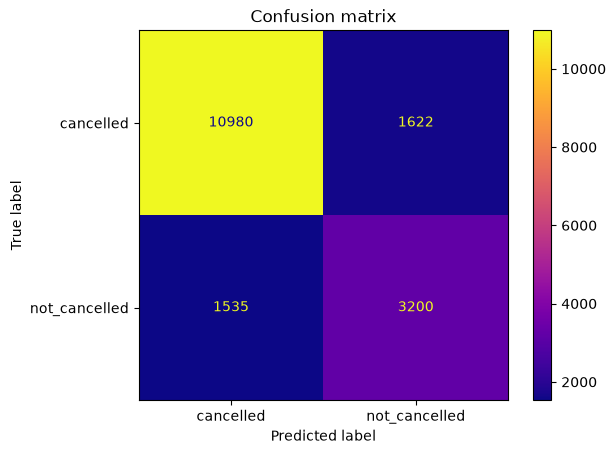

In [52]:
test_model(y_test, preds, ['cancelled', 'not_cancelled'])